In [44]:
import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = '../examples/comparisons/combined_boundary_DIIID'
SWEEPS = {'convergence_w5_b_temp': 'Bayesian', 'convergence_w5_l_temp': 'Multi-start L-BFGS'}
N_COILS = 5
CFG_RE = re.compile(r'alpha:[^,]+,weight:([^,]+),lambda:([^,]+),coils:(\d+)')

In [45]:
def load_sweep(sweep, method, n_coils):
    rows = []
    sweep_dir = os.path.join(BASE, sweep)
    for cfg in sorted(os.listdir(sweep_dir)):
        m = CFG_RE.match(cfg)
        if not m:
            continue
        weight, lam, coils = float(m.group(1)), float(m.group(2)), int(m.group(3))
        if coils != n_coils:
            continue
        cfg_dir = os.path.join(sweep_dir, cfg)
        for run in sorted(os.listdir(cfg_dir)):
            rpath = os.path.join(cfg_dir, run, 'results.json')
            if not os.path.exists(rpath):
                rpath = os.path.join(cfg_dir, run, 'checkpoint.json')
            if not os.path.exists(rpath):
                continue
            d = json.load(open(rpath))
            inner = d.get('methods', {}).get(method)
            if inner is None:
                continue
            I = np.abs(np.array(inner.get('coil_currents', [])))
            if I.size == 0:
                continue
            rows.append({
                'sweep': sweep,
                'method': method,
                'weight_fb': weight,
                'lambda': lam,
                'num_coils': coils,
                'total_current': float(I.sum()),
                'max_current': float(I.max()),
                'l2_current': float(np.sqrt((I**2).sum())),
                'best_flux_err': inner.get('best_flux_err', float('nan')),
                'best_fb_cost': inner.get('best_fb_cost', float('nan')),
                'best_cost': inner.get('best_cost', float('nan')),
            })
    return rows

all_rows = []
for sweep, method in SWEEPS.items():
    all_rows += load_sweep(sweep, method, N_COILS)

df = pd.DataFrame(all_rows).sort_values(['method', 'weight_fb']).reset_index(drop=True)
print(f'rows={len(df)}')
df

rows=8


,sweep,method,weight_fb,lambda,num_coils,total_current,max_current,l2_current,best_flux_err,best_fb_cost,best_cost
0,convergence_w5_b_temp,Bayesian,0.0001,0.000001,5,124900.771091,30622.066327,48122.852869,0.003740,0.000035,0.010973
1,convergence_w5_b_temp,Bayesian,0.0010,0.000001,5,124900.771091,30622.066327,48122.852869,0.003740,0.000035,0.016358
2,convergence_w5_b_temp,Bayesian,0.0100,0.000001,5,182235.927205,34113.333878,63505.801742,0.005490,0.000015,0.008080
3,convergence_w5_b_temp,Bayesian,0.1000,0.000001,5,133294.836203,25871.365291,47585.165254,0.002754,0.000213,0.072033
4,convergence_w5_l_temp,Multi-start L-BFGS,0.0001,0.000001,5,161832.456560,24994.709180,55383.244090,0.003867,0.000051,0.007961
5,convergence_w5_l_temp,Multi-start L-BFGS,0.0010,0.000001,5,121100.000195,42039.380981,56528.071164,0.004388,0.000081,0.004500
6,convergence_w5_l_temp,Multi-start L-BFGS,0.0100,0.000001,5,119228.135057,42055.973032,55803.328609,0.004180,0.000085,0.005731
7,convergence_w5_l_temp,Multi-start L-BFGS,0.1000,0.000001,5,113565.894448,41591.567814,54220.273299,0.004457,0.000386,0.018396


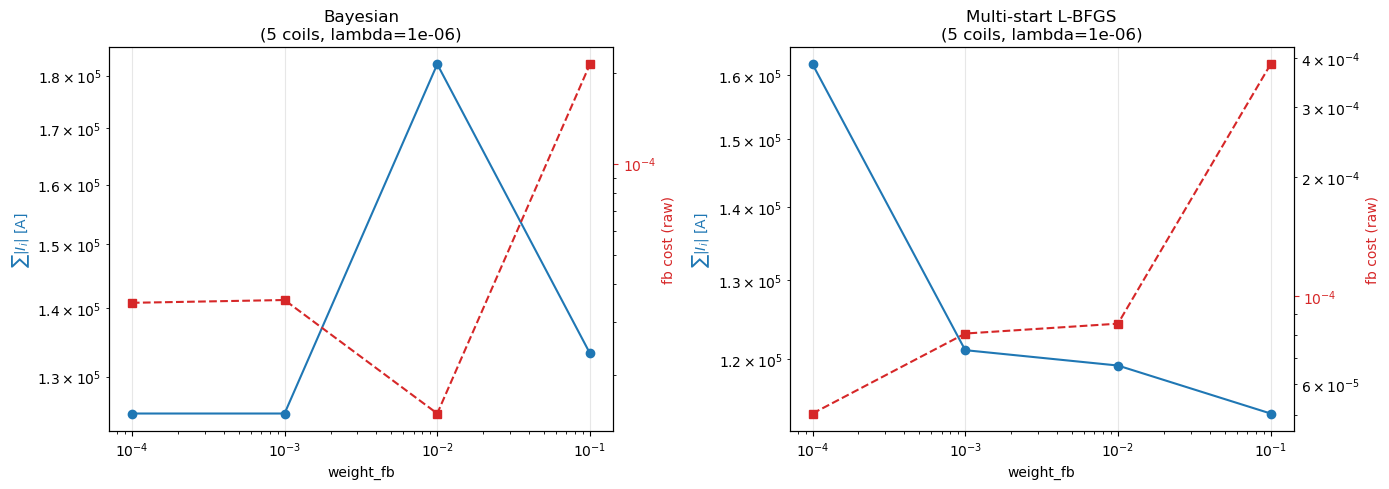

In [47]:
RIGHT_METRIC = 'best_fb_cost'
RIGHT_LABEL = 'fb cost (raw)'
RIGHT_LOG = True

methods = list(SWEEPS.values())
fig, axes = plt.subplots(1, len(methods), figsize=(7 * len(methods), 5), squeeze=False)
for ax1, method in zip(axes[0], methods):
    sub = df[df['method'] == method].sort_values('weight_fb')
    ax2 = ax1.twinx()
    ax1.plot(sub['weight_fb'], sub['total_current'], 'o-', color='tab:blue', lw=1.5, ms=6)
    ax2.plot(sub['weight_fb'], sub[RIGHT_METRIC], 's--', color='tab:red', lw=1.5, ms=6)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    if RIGHT_LOG:
        ax2.set_yscale('log')
    ax1.set_xlabel('weight_fb')
    ax1.set_ylabel(r'$\sum|I_i|$ [A]', color='tab:blue')
    ax2.set_ylabel(RIGHT_LABEL, color='tab:red')
    ax1.tick_params(axis='y', colors='tab:blue')
    ax2.tick_params(axis='y', colors='tab:red')
    lam_str = f'{sub["lambda"].iloc[0]:.0e}' if len(sub) else 'n/a'
    ax1.set_title(f'{method}\n({N_COILS} coils, lambda={lam_str})')
    ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
def load_sweep_all_coils(sweep, method):
    rows = []
    sweep_dir = os.path.join(BASE, sweep)
    for cfg in sorted(os.listdir(sweep_dir)):
        m = CFG_RE.match(cfg)
        if not m:
            continue
        weight, lam, coils = float(m.group(1)), float(m.group(2)), int(m.group(3))
        cfg_dir = os.path.join(sweep_dir, cfg)
        for run in sorted(os.listdir(cfg_dir)):
            rpath = os.path.join(cfg_dir, run, 'results.json')
            if not os.path.exists(rpath):
                rpath = os.path.join(cfg_dir, run, 'checkpoint.json')
            if not os.path.exists(rpath):
                continue
            d = json.load(open(rpath))
            inner = d.get('methods', {}).get(method)
            if inner is None:
                continue
            I = np.abs(np.array(inner.get('coil_currents', [])))
            if I.size == 0:
                continue
            rows.append({
                'sweep': sweep,
                'method': method,
                'weight_fb': weight,
                'lambda': lam,
                'num_coils': coils,
                'total_current': float(I.sum()),
                'max_current': float(I.max()),
                'l2_current': float(np.sqrt((I**2).sum())),
                'best_flux_err': inner.get('best_flux_err', float('nan')),
                'best_fb_cost': inner.get('best_fb_cost', float('nan')),
                'best_cost': inner.get('best_cost', float('nan')),
            })
    return rows

all_rows_full = []
for sweep, method in SWEEPS.items():
    all_rows_full += load_sweep_all_coils(sweep, method)
df_full = pd.DataFrame(all_rows_full).sort_values(['method', 'num_coils', 'weight_fb']).reset_index(drop=True)
print(f'rows={len(df_full)}')
df_full

rows=32


,sweep,method,weight_fb,lambda,num_coils,total_current,max_current,l2_current,best_flux_err,best_fb_cost,best_cost
0,convergence_w5_b_temp,Bayesian,0.0001,0.000001,2,59070.431159,26655.581516,33696.596710,0.017855,0.002121,1.368086e-01
1,convergence_w5_b_temp,Bayesian,0.0010,0.000001,2,57915.772264,26323.046472,33204.817206,0.017553,0.002049,1.321532e-01
2,convergence_w5_b_temp,Bayesian,0.0100,0.000001,2,86905.383596,34345.044869,46812.160615,0.019162,0.001986,1.283466e-01
3,convergence_w5_b_temp,Bayesian,0.1000,0.000001,2,63594.401855,24411.458791,34377.664075,0.021173,0.002252,1.653359e-01
4,convergence_w5_b_temp,Bayesian,0.0001,0.000001,3,138027.159964,54340.842023,70407.163059,0.008221,0.000059,1.578926e-01
5,convergence_w5_b_temp,Bayesian,0.0010,0.000001,3,138027.159964,54340.842023,70407.163059,0.008221,0.000059,1.579208e-01
6,convergence_w5_b_temp,Bayesian,0.0100,0.000001,3,138027.159964,54340.842023,70407.163059,0.008221,0.000059,1.595804e-01
7,convergence_w5_b_temp,Bayesian,0.1000,0.000001,3,149316.160782,31088.055009,61947.473526,0.008605,0.000973,5.527488e-01
8,convergence_w5_b_temp,Bayesian,0.0001,0.000001,4,168740.957237,35202.441726,65148.970952,0.006613,0.000074,2.295708e-01
9,convergence_w5_b_temp,Bayesian,0.0010,0.000001,4,168740.957237,35202.441726,65148.970952,0.006613,0.000074,2.300227e-01


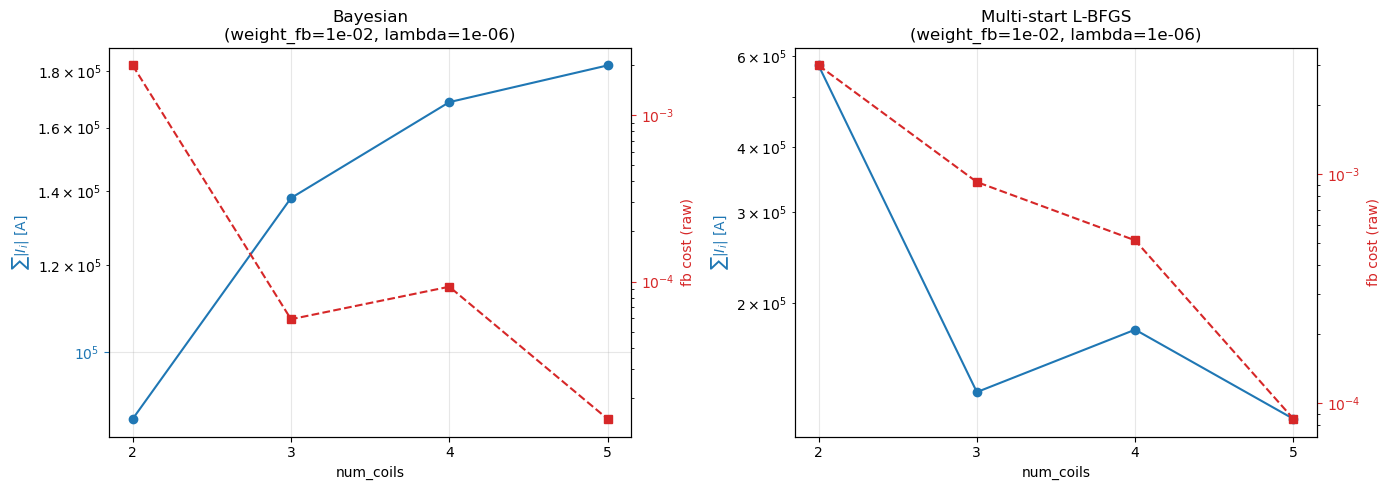

In [54]:
FIXED_WEIGHT = 1e-02
RIGHT_METRIC = 'best_fb_cost'
RIGHT_LABEL = 'fb cost (raw)'
RIGHT_LOG = True

methods = list(SWEEPS.values())
fig, axes = plt.subplots(1, len(methods), figsize=(7 * len(methods), 5), squeeze=False)
for ax1, method in zip(axes[0], methods):
    sub = df_full[(df_full['method'] == method) & (np.isclose(df_full['weight_fb'], FIXED_WEIGHT))].sort_values('num_coils')
    ax2 = ax1.twinx()
    ax1.plot(sub['num_coils'], sub['total_current'], 'o-', color='tab:blue', lw=1.5, ms=6)
    ax2.plot(sub['num_coils'], sub[RIGHT_METRIC], 's--', color='tab:red', lw=1.5, ms=6)
    ax1.set_yscale('log')
    if RIGHT_LOG:
        ax2.set_yscale('log')
    ax1.set_xticks(sorted(df_full['num_coils'].unique()))
    ax1.set_xlabel('num_coils')
    ax1.set_ylabel(r'$\sum|I_i|$ [A]', color='tab:blue')
    ax2.set_ylabel(RIGHT_LABEL, color='tab:red')
    ax1.tick_params(axis='y', colors='tab:blue')
    ax2.tick_params(axis='y', colors='tab:red')
    lam_str = f'{sub["lambda"].iloc[0]:.0e}' if len(sub) else 'n/a'
    ax1.set_title(f'{method}\n(weight_fb={FIXED_WEIGHT:.0e}, lambda={lam_str})')
    ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()